In [ ]:
!pip install econml causalgraphicalmodels


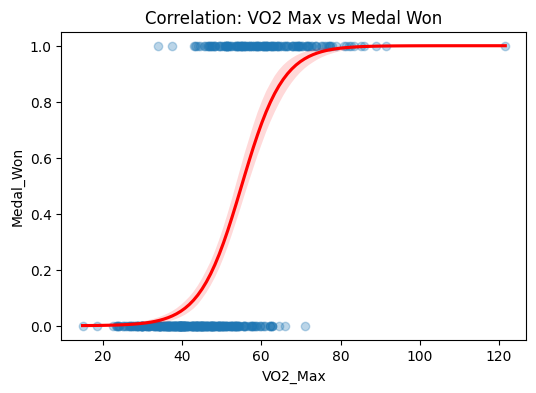


Estimated Causal Effect (ATE): 0.0230

Rendering Saved DAG:


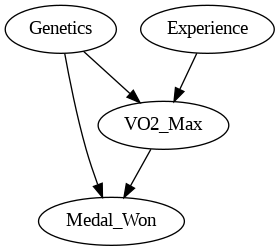

In [ ]:
import collections
if not hasattr(collections, 'Iterable'):
    import collections.abc
    collections.Iterable = collections.abc.Iterable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
from causalgraphicalmodels import CausalGraphicalModel
from IPython.display import Image, display  # <--- Added for rendering

# --- 1. Data Generation ---
np.random.seed(42)
n = 500
vo2_max = np.random.gamma(shape=12, scale=4, size=n)
k, x0 = 0.2, 55
prob_winning = 1 / (1 + np.exp(-k * (vo2_max - x0)))
medal_won = np.random.binomial(1, prob_winning)

df = pd.DataFrame({
    'VO2_Max': vo2_max,
    'Medal_Won': medal_won,
    'Experience': np.random.choice([1, 2, 3], n, p=[0.5, 0.3, 0.2]),
    'Heart_Rate': np.random.normal(165, 12, n)
})

# --- 2. Visualization ---
plt.figure(figsize=(6, 4))
sns.regplot(x='VO2_Max', y='Medal_Won', data=df, logistic=True,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Correlation: VO2 Max vs Medal Won")
plt.savefig('viz.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Causal Forest Approach ---
Y = df['Medal_Won'].values.flatten()
T = df['VO2_Max'].values.flatten()
X_cov = df[['Experience', 'Heart_Rate']].values

est = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=10),
    model_t=RandomForestRegressor(n_estimators=100, min_samples_leaf=10),
    discrete_treatment=False
)

est.fit(Y, T, X=X_cov)
ate = est.ate(X_cov)
print(f"\nEstimated Causal Effect (ATE): {ate:.4f}\n")

# --- 4. DAG Approach ---
dag = CausalGraphicalModel(
    nodes=["Experience", "VO2_Max", "Medal_Won", "Genetics"],
    edges=[("Experience", "VO2_Max"), ("VO2_Max", "Medal_Won"),
           ("Genetics", "VO2_Max"), ("Genetics", "Medal_Won")]
)

# Render the DAG to a file
dag.draw().render('dag', format='png')

# --- 5. Display the saved PNGs in Colab ---
print("Rendering Saved DAG:")
display(Image('dag.png'))

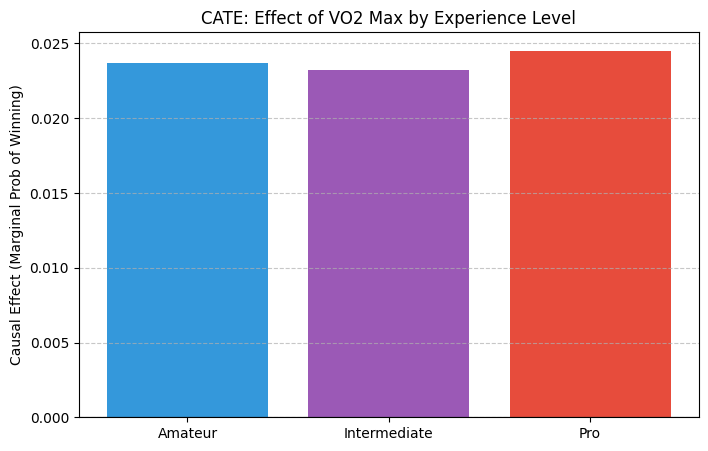

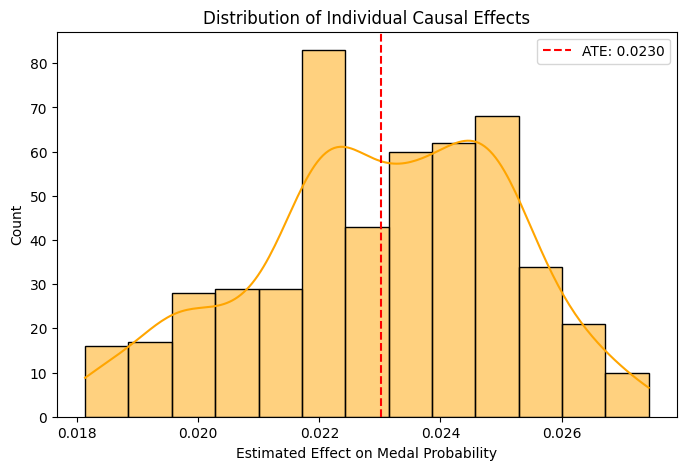

In [ ]:
# --- 6. CATE Analysis (Heterogeneous Effects) ---

# We want to see how the effect of VO2 Max varies across Experience levels
# Create a range of Experience levels (1: Amateur, 2: Int, 3: Pro)
exp_test = np.array([[1, 165], [2, 165], [3, 165]]) # HR fixed at mean
cate_estimates = est.effect(exp_test)

plt.figure(figsize=(8, 5))
plt.bar(['Amateur', 'Intermediate', 'Pro'], cate_estimates, color=['#3498db', '#9b59b6', '#e74c3c'])
plt.axhline(0, color='black', lw=0.8)
plt.ylabel("Causal Effect (Marginal Prob of Winning)")
plt.title("CATE: Effect of VO2 Max by Experience Level")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('cate_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 7. Distribution of Effects ---
# Get individual effects for every runner in the dataset
test_effects = est.effect(X_cov)

plt.figure(figsize=(8, 5))
sns.histplot(test_effects, kde=True, color='orange')
plt.axvline(ate, color='red', linestyle='--', label=f'ATE: {ate:.4f}')
plt.title("Distribution of Individual Causal Effects")
plt.xlabel("Estimated Effect on Medal Probability")
plt.legend()
plt.savefig('cate_dist.png', dpi=300, bbox_inches='tight')
plt.show()

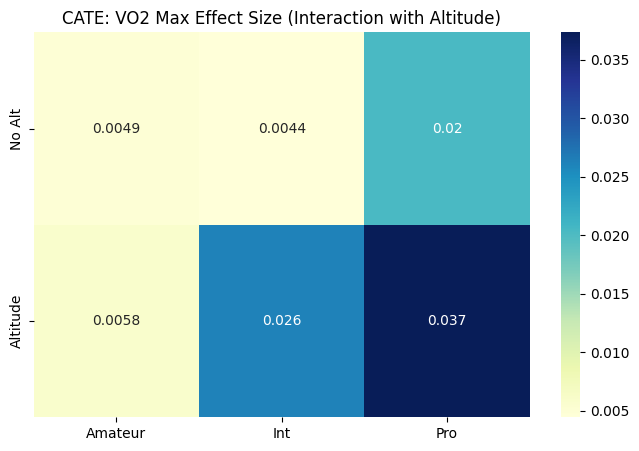


--- Structural Causal Model (DAG) ---


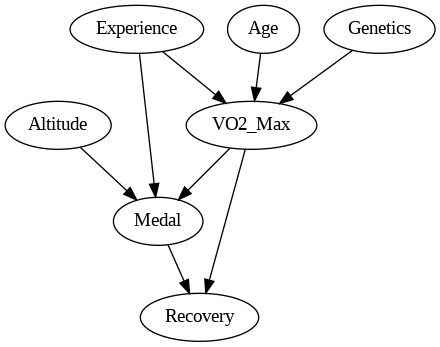


Average Treatment Effect (ATE): 0.0126


In [ ]:
import collections
if not hasattr(collections, 'Iterable'):
    import collections.abc
    collections.Iterable = collections.abc.Iterable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
from causalgraphicalmodels import CausalGraphicalModel
from IPython.display import Image, display # For rendering PNGs in Colab

# --- 1. Enhanced Data Generation ---
np.random.seed(42)
n = 1000

age = np.random.randint(18, 60, n)
experience = np.random.choice([1, 2, 3], n, p=[0.4, 0.4, 0.2])
altitude_training = np.random.binomial(1, 0.3, n)
genetics_score = np.random.beta(2, 5, n) * 100

vo2_max = (genetics_score * 0.4) + (experience * 5) - (age * 0.1) + np.random.normal(20, 5, n)

logit_win = -8 + (0.12 * vo2_max) + (0.5 * experience) + (0.8 * altitude_training * (vo2_max/50))
prob_winning = 1 / (1 + np.exp(-logit_win))
medal_won = np.random.binomial(1, prob_winning)

recovery_post = (0.5 * vo2_max) + (10 * medal_won) + np.random.normal(0, 5, n)

df = pd.DataFrame({
    'VO2_Max': vo2_max, 'Medal_Won': medal_won, 'Age': age,
    'Experience': experience, 'Altitude': altitude_training,
    'Genetics': genetics_score, 'Recovery': recovery_post
})

# --- 2. Causal Forest with Interaction Analysis ---
Y = df['Medal_Won'].values
T = df['VO2_Max'].values
X_cov = df[['Age', 'Experience', 'Altitude']].values

est = CausalForestDML(model_y=RandomForestRegressor(), model_t=RandomForestRegressor())
est.fit(Y, T, X=X_cov)

# --- 3. Visualization: CATE Heatmap (Experience vs Altitude) ---
exp_grid, alt_grid = np.meshgrid([1, 2, 3], [0, 1])
X_test = np.c_[np.full(6, 30), exp_grid.ravel(), alt_grid.ravel()]
effects = est.effect(X_test).reshape(2, 3)

plt.figure(figsize=(8, 5))
sns.heatmap(effects, annot=True, xticklabels=['Amateur', 'Int', 'Pro'],
            yticklabels=['No Alt', 'Altitude'], cmap='YlGnBu')
plt.title("CATE: VO2 Max Effect Size (Interaction with Altitude)")
plt.savefig('cate_heatmap.png', dpi=300)
plt.show() # Shows the heatmap immediately

# --- 4. DAG for expanded variables ---
dag = CausalGraphicalModel(
    nodes=["Genetics", "Age", "Experience", "VO2_Max", "Altitude", "Medal", "Recovery"],
    edges=[
        ("Genetics", "VO2_Max"), ("Age", "VO2_Max"), ("Experience", "VO2_Max"),
        ("VO2_Max", "Medal"), ("Altitude", "Medal"), ("Experience", "Medal"),
        ("VO2_Max", "Recovery"), ("Medal", "Recovery")
    ]
)

# Render DAG to file
dag.draw().render('dag_complex', format='png')

# --- 5. Display the Complex DAG in Colab ---
print("\n--- Structural Causal Model (DAG) ---")
display(Image('dag_complex.png'))

# Summary Stats for your LaTeX "Key Findings" box
ate = est.ate(X_cov)
print(f"\nAverage Treatment Effect (ATE): {ate:.4f}")